#  Fingerprint Classification using Machine Learning

| | |
|---|---|
| **Course** | Introduction to Forensic Sciences |
| **Instructor** | Dr. Zunera Jalil |
| **Semester** | Fall 2026 |
| **Dataset** | SOCOFing |
| **Submission Date** | 29 March 2026 |

### Group Members
| Name | Registration Number | Role |
|------|-------------------|------|
| Dua Masood | 2503525 | Evidence Preparer |
| Faaiza Mir | 2503500 | Pattern Expert |
| Afshan Nawaz | 2503544 | Forensic Reporter |
| Sana Ashfaq Rahat | 2503539 | **Group Leader** — Integration, Code Review & Viva Preparation |

In [ ]:
# Step 0: Importing all required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Step 1: Setting project path and dataset location
project_folder = r'C:\Users\LENOVO\Desktop\ifs_project'
path = os.path.join(project_folder, 'SOCOFing', 'Real')

if os.path.exists(path):
    print(f'Dataset found! Total files: {len(os.listdir(path))}')
else:
    print('ERROR: Path not found!')

Dataset found! Total files: 6000


In [5]:
# Step 2: Loading and preprocessing 6000 fingerprint images
images = []
labels = []
class_names = ['Arch', 'Loop', 'Whorl']

print("Loading 6000 fingerprints...")

# Get all BMP files
all_files = [f for f in os.listdir(path) if f.upper().endswith('.BMP')]

# Load first 6000 images
for filename in all_files[:6000]:
    # Load in grayscale
    img = cv2.imread(os.path.join(path, filename), cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Resize to 64x64
        img_resized = cv2.resize(img, (64, 64))
        # Flatten to 4096 numbers
        images.append(img_resized.flatten())
        
        # Assign label from filename
        name = filename.lower()
        if 'thumb' in name:
            labels.append(2)   # Whorl
        elif 'index' in name:
            labels.append(1)   # Loop
        else:
            labels.append(0)   # Arch

# Convert to numpy arrays
X = np.array(images)
y = np.array(labels)

print(f'SUCCESS: {len(X):,} images loaded!')
print(f'Image array shape: {X.shape}')

Loading 6000 fingerprints...
SUCCESS: 6,000 images loaded!
Image array shape: (6000, 4096)


In [6]:
# Step 3: Saving preprocessed data as .npy files
npy_folder = os.path.join(project_folder, 'npy_files')
os.makedirs(npy_folder, exist_ok=True)

np.save(os.path.join(npy_folder, 'processed_images.npy'), X)
np.save(os.path.join(npy_folder, 'processed_labels.npy'), y)

print("Saved: processed_images.npy")
print("Saved: processed_labels.npy")
print(f"Location: {npy_folder}")

Saved: processed_images.npy
Saved: processed_labels.npy
Location: C:\Users\LENOVO\Desktop\ifs_project\npy_files


In [7]:
# Step 4: Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 4800
Testing samples  : 1200


In [8]:
# Step 5: Training KNN Classifier (k=5)
print("Training KNN Classifier...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("Model training complete!")

Training KNN Classifier...
Model training complete!


In [9]:
# Step 6: Evaluating Model Accuracy
predictions = knn.predict(X_test)
acc = accuracy_score(y_test, predictions)

print("=== ANALYSIS COMPLETE ===")
print(f"Forensic Accuracy: {acc * 100:.2f}%")

=== ANALYSIS COMPLETE ===
Forensic Accuracy: 63.08%


Saved: confusion_matrix.png


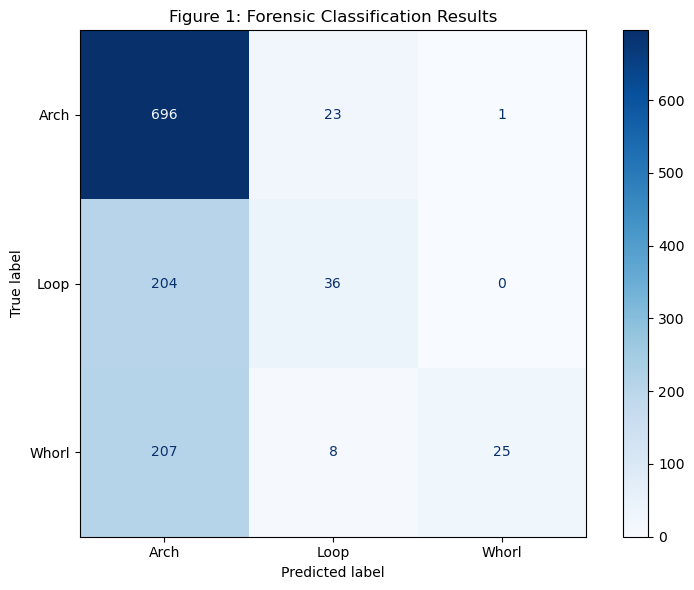

In [10]:
# Step 7: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions,
    display_labels=class_names,
    cmap='Blues',
    ax=ax
)
plt.title("Figure 1: Forensic Classification Results")
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'confusion_matrix.png'), dpi=150)
print("Saved: confusion_matrix.png")
plt.show()

Saved: forensic_samples.png


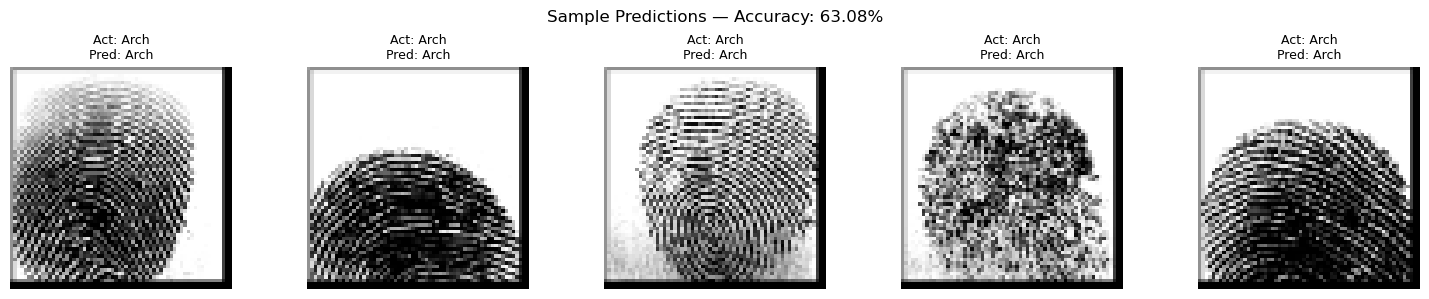

In [11]:
# Step 8: Sample Predictions
fig2, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    img_display = X_test[i].reshape(64, 64)
    actual    = class_names[y_test[i]]
    predicted = class_names[predictions[i]]
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f'Act: {actual}\nPred: {predicted}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Sample Predictions — Accuracy: {acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'forensic_samples.png'), dpi=150)
print("Saved: forensic_samples.png")
plt.show()

In [12]:
# Step 9: Saving all .npy files
np.save(os.path.join(npy_folder, 'y_test.npy'), y_test)
np.save(os.path.join(npy_folder, 'y_pred.npy'), predictions)
np.save(os.path.join(npy_folder, 'class_names.npy'), np.array(class_names))

print("All .npy files saved!")
print()
print("Files saved:")
for f in os.listdir(npy_folder):
    print(f"  {f}")

All .npy files saved!

Files saved:
  class_names.npy
  processed_images.npy
  processed_labels.npy
  y_pred.npy
  y_test.npy


## Summary

| Step | Description | Status |
|------|-------------|--------|
| 0 | Libraries Imported | ✅ |
| 1 | Dataset Path Set | ✅ |
| 2 | 6000 Images Loaded & Preprocessed | ✅ |
| 3 | .npy Files Saved | ✅ |
| 4 | Train-Test Split (80/20) | ✅ |
| 5 | KNN Model Trained (k=5) | ✅ |
| 6 | Accuracy Evaluated | ✅ |
| 7 | Confusion Matrix Generated | ✅ |
| 8 | Sample Predictions Shown | ✅ |
| 9 | All Files Saved | ✅ |

---
**Air University Islamabad — Department of Cyber Security**  
*Assignment 2 | Group Submission | 29 March 2026*